# The next hypothesis test

In [1161]:
an_extend

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,Dog,Labrador,4,25.0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,120,39.5,1
1,Dog,Beagle,1,10.0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,130,39.2,2
2,Dog,German Shepherd,3,30.0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,110,39.3,3
3,Dog,Bulldog,5,23.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,115,40.0,4
4,Dog,Poodle,2,12.0,1,1,0,1,0,0,...,0,1,0,0,0,0,0,115,39.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Pig,Yorkshire,2,110.0,1,1,1,1,0,1,...,0,1,0,0,0,0,0,105,39.6,128
2107,Pig,Yorkshire,2,110.0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,100,39.2,130
2108,Pig,Yorkshire,2,110.0,0,1,1,1,1,0,...,0,0,0,0,1,0,0,87,39.8,129
2109,Pig,Yorkshire,2,110.0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,95,39.1,128


## Hypothesis: 'Age' feature is not important 

In [1162]:
an_copy = an_extend.copy()

In [1163]:
an_copy.drop(columns=['Age'], inplace=True)

In [1164]:
animals_copy = new_an.copy()

In [1165]:
animals_rank = {}
breeds = {}
for i, a in enumerate(animals_copy['Animal_Type'].unique(), 1):
    animals_rank[a] = i

animals_copy['Animal_Type'] = animals_copy['Animal_Type'].map(func=lambda x: animals_rank[x])
animals_copy.head()

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,1,Labrador,4,25.0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,120,39.5,Parvovirus
1,2,Siamese,2,4.5,0,0,0,1,0,0,...,1,0,0,0,0,0,0,150,38.9,Upper Respiratory Infection
2,3,Holstein,3,600.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,90,40.1,Foot and Mouth Disease
3,1,Beagle,1,10.0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,130,39.2,Gastroenteritis
4,2,Persian,5,3.8,1,0,0,0,0,0,...,0,1,0,0,0,0,0,160,38.7,Fungal Infection


### Create dict with all breeds for each type of animal

In [1166]:
part = animals_copy.groupby('Animal_Type')['Breed'].value_counts()
i = 1
for a, b in part.index:
    if a not in breeds:
        breeds[a] = [(i, b)]
        continue
    else:
        i = breeds[a][-1][0]
        breeds[a].append((i + 1, b))
        i = 1
        continue
breeds

{1: [(1, 'Beagle'),
  (2, 'Chihuahua'),
  (3, 'Golden Retriever'),
  (4, 'Poodle'),
  (5, 'German Shepherd'),
  (6, 'Bulldog'),
  (7, 'Rottweiler'),
  (8, 'Dachshund'),
  (9, 'Shih Tzu'),
  (10, 'Boxer'),
  (11, 'Labrador'),
  (12, 'Cocker Spaniel'),
  (13, 'Siberian Husky'),
  (14, 'Husky'),
  (15, 'Border Collie'),
  (16, 'Corgi'),
  (17, 'Dalmatian'),
  (18, 'Labrador Retriever'),
  (19, 'Akita'),
  (20, 'Pit Bull'),
  (21, 'Yorkshire Terrier'),
  (22, 'Doberman Pinscher')],
 2: [(1, 'Maine Coon'),
  (2, 'Persian'),
  (3, 'Bengal'),
  (4, 'Siamese'),
  (5, 'Abyssinian'),
  (6, 'Sphynx'),
  (7, 'Russian Blue'),
  (8, 'Scottish Fold'),
  (9, 'Ragdoll'),
  (10, 'British Shorthair'),
  (11, 'Siberian'),
  (12, 'Burmese'),
  (13, 'Devon Rex'),
  (14, 'Bombay'),
  (15, 'American Curl'),
  (16, 'Manx')],
 3: [(1, 'Jersey'),
  (2, 'Holstein'),
  (3, 'Angus'),
  (4, 'Guernsey'),
  (5, 'Hereford'),
  (6, 'Simmental'),
  (7, 'Ayrshire'),
  (8, 'Charolais'),
  (9, 'Limousin'),
  (10, 'Brahman')

In [1167]:
def breed_transform(r, breeds):
    '''Function that will transform 'Breed' feature to a form float('animal_type_number'.'animal_breed_number')'''
    animal_breeds = breeds[r['Animal_Type']]
    idx = [x[1] for x in animal_breeds].index(r['Breed'])
    return float(f'{r['Animal_Type']}.{animal_breeds[idx][0]}') if animal_breeds[idx][0] > 9 else float(f'{r['Animal_Type']}.0{animal_breeds[idx][0]}')

animals_copy['Breed'] = animals_copy.apply(func=breed_transform, axis=1, args=(breeds,))

In [1168]:
animals_copy.head()

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,1,1.11,4,25.0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,120,39.5,Parvovirus
1,2,2.04,2,4.5,0,0,0,1,0,0,...,1,0,0,0,0,0,0,150,38.9,Upper Respiratory Infection
2,3,3.02,3,600.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,90,40.1,Foot and Mouth Disease
3,1,1.01,1,10.0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,130,39.2,Gastroenteritis
4,2,2.02,5,3.8,1,0,0,0,0,0,...,0,1,0,0,0,0,0,160,38.7,Fungal Infection


In [1169]:
disease_rank = {}
diseases = animals_copy['Disease_Prediction'].unique()
for i in range(len(diseases)):
    disease_rank[diseases[i]] = i + 1

animals_copy['Disease_Prediction'] = animals_copy['Disease_Prediction'].map(func=lambda x: disease_rank[x])
animals_copy.head()

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,1,1.11,4,25.0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,120,39.5,1
1,2,2.04,2,4.5,0,0,0,1,0,0,...,1,0,0,0,0,0,0,150,38.9,2
2,3,3.02,3,600.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,90,40.1,3
3,1,1.01,1,10.0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,130,39.2,4
4,2,2.02,5,3.8,1,0,0,0,0,0,...,0,1,0,0,0,0,0,160,38.7,5


In [1170]:
disease_rank

{'Parvovirus': 1,
 'Upper Respiratory Infection': 2,
 'Foot and Mouth Disease': 3,
 'Gastroenteritis': 4,
 'Fungal Infection': 5,
 'Equine Influenza': 6,
 'Lyme Disease': 7,
 'Intestinal Parasites': 8,
 'Canine Distemper': 9,
 'Mastitis': 10,
 'Panleukopenia': 11,
 'Kennel Cough': 12,
 'Strangles': 13,
 'Bovine Respiratory Disease': 14,
 'Canine Parvovirus': 15,
 'Ringworm': 16,
 'Tick-Borne Disease': 17,
 'Arthritis': 18,
 'Feline Herpesvirus': 19,
 'Equine Rhinopneumonitis': 20,
 'Feline Leukemia': 21,
 'Heartworm Disease': 22,
 'Feline Infectious Peritonitis': 23,
 'Equine Viral Arteritis': 24,
 "Johne's Disease": 25,
 'Conjunctivitis': 26,
 'Equine Piroplasmosis': 27,
 'Salmonellosis': 28,
 'Chronic Bronchitis': 29,
 'Feline Upper Respiratory Infection': 30,
 'Equine Arthritis': 31,
 'Equine Infectious Anemia': 32,
 'Bovine Viral Diarrhea': 33,
 'Pancreatitis': 34,
 'Equine Pneumonia': 35,
 'Feline Calicivirus': 36,
 'Laminitis': 37,
 'Cryptosporidiosis': 38,
 'Bordetella Infection

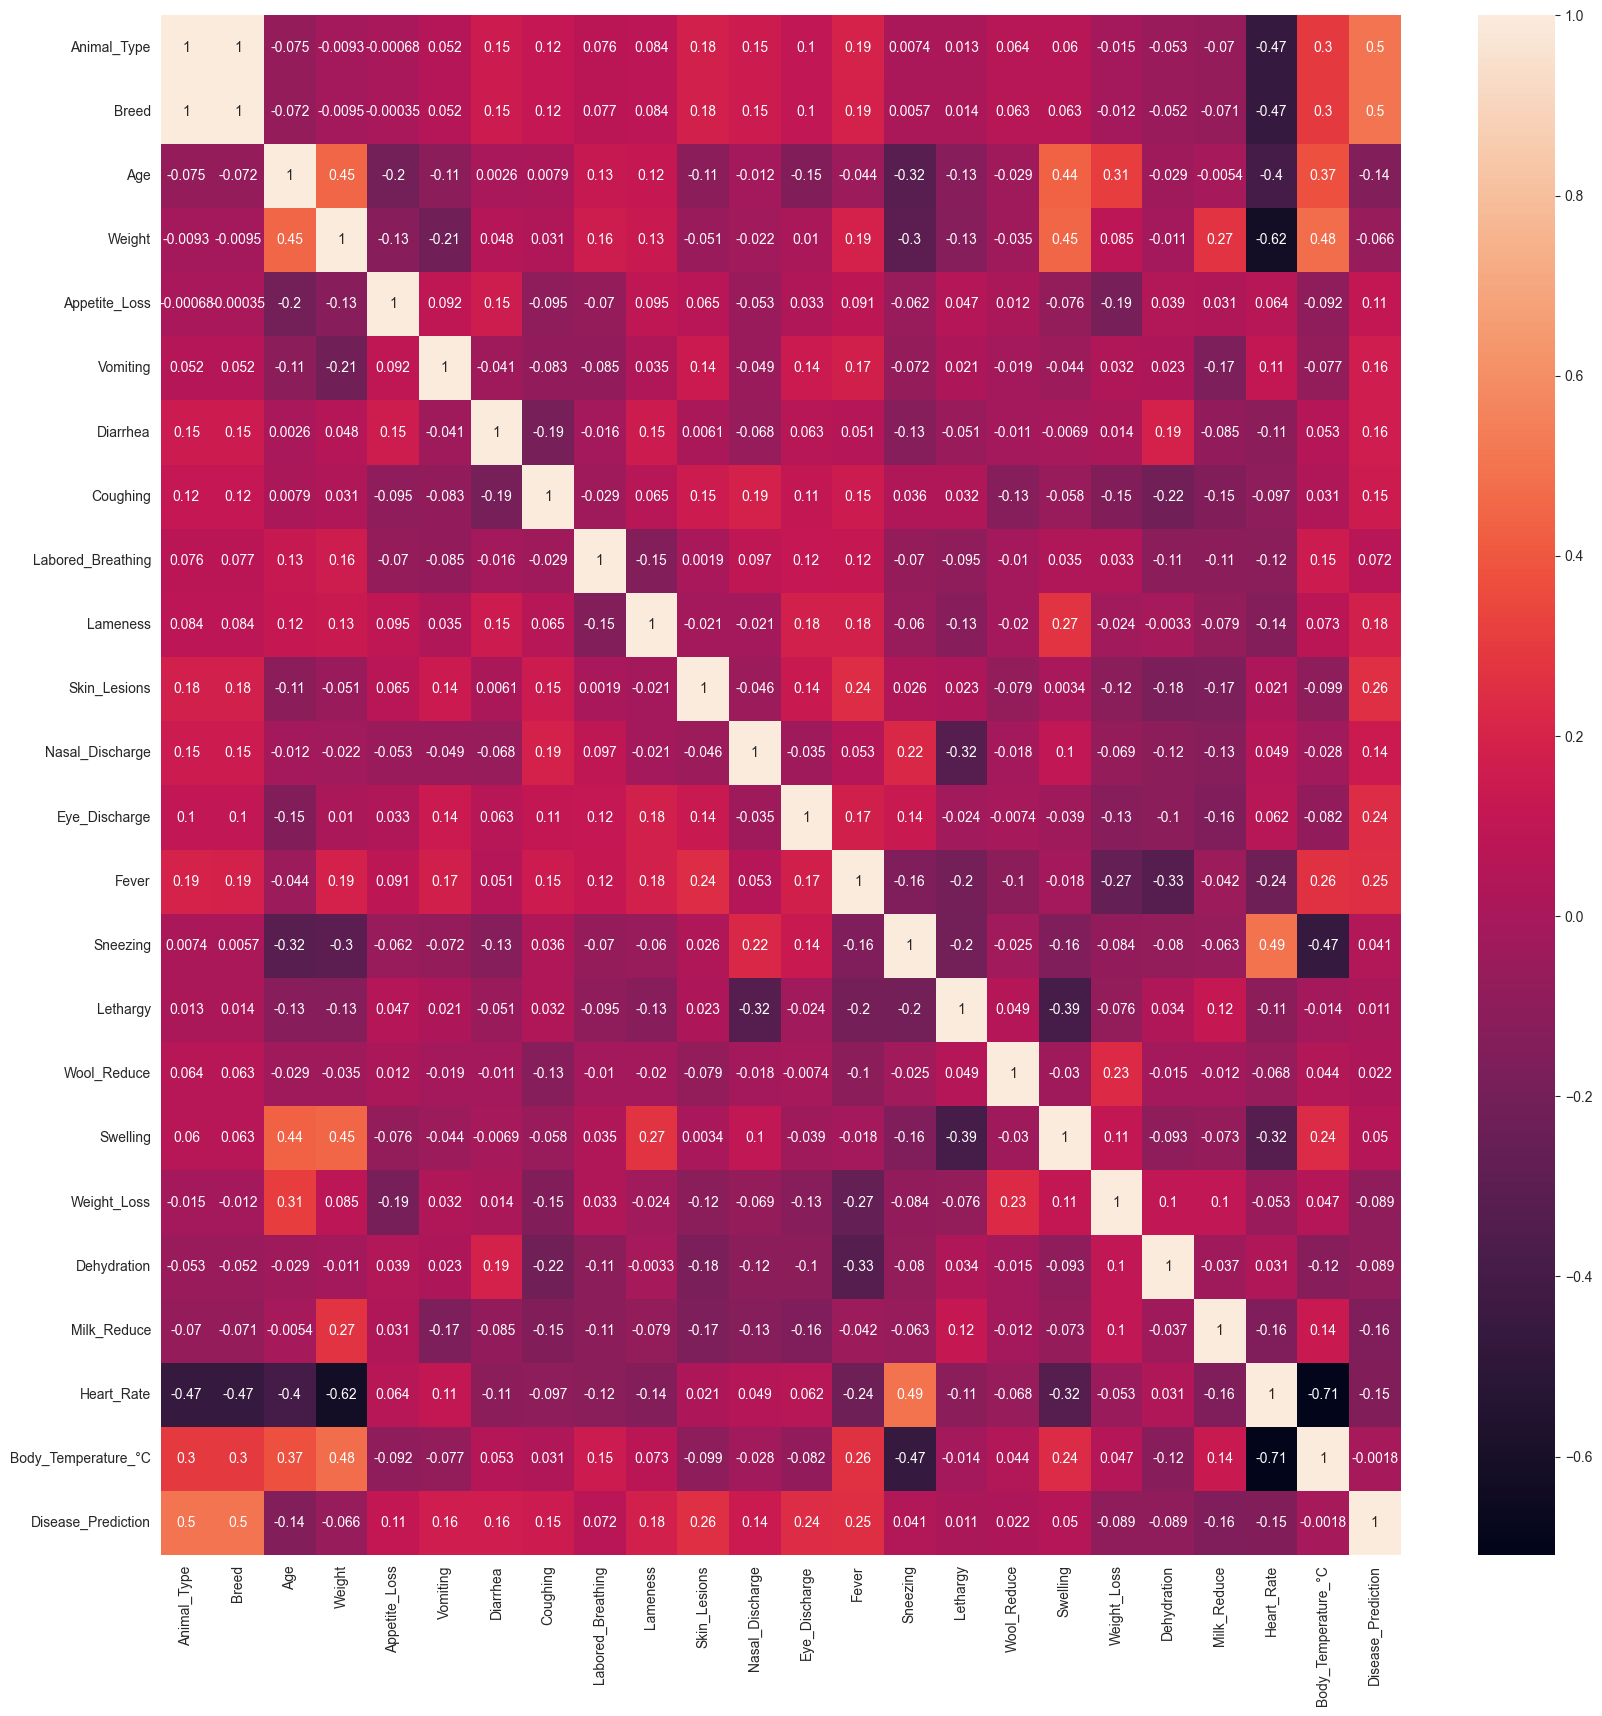

In [1171]:
corr_mat = animals_copy.corr()

plt.figure(figsize=(20, 20))

sns.heatmap(corr_mat, annot=True)

plt.show()

In [1172]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from transf_mod import CategoricalImputer, NumericalImputer

## Split data

In [414]:
Features, target = an_copy.drop(columns=['Disease_Prediction']), an_copy['Disease_Prediction']


In [415]:
F_train, F_test, t_train, t_test = train_test_split(Features, target, test_size=0.2, random_state=65)

## Categorical, numerical and still feature definition

In [62]:
cat_feat = ['Animal_Type', 'Breed']
num_feat = ['Weight', 'Heart_Rate', 'Body_Temperature_°C']
still = [x for x in F_train.drop(columns=['Breed', 'Weight', 'Heart_Rate', 'Body_Temperature_°C', 'Animal_Type']).columns]
still

['Appetite_Loss',
 'Vomiting',
 'Diarrhea',
 'Coughing',
 'Labored_Breathing',
 'Lameness',
 'Skin_Lesions',
 'Nasal_Discharge',
 'Eye_Discharge',
 'Fever',
 'Dehydration',
 'Sneezing',
 'Weight_Loss',
 'Lethargy',
 'Swelling',
 'Milk_Reduce',
 'Wool_Reduce']

## Main pipeline create process

In [63]:
pre_pipe = Pipeline(steps=[('cat', CategoricalImputer()), ('num', NumericalImputer())])

In [64]:
first_pipe = Pipeline(steps=[('onehot', OneHotEncoder(sparse_output=False))])
second_pipe = Pipeline(steps=[('scale', RobustScaler())])
thr_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))])

In [65]:
preproc = ColumnTransformer(transformers=[('cats', first_pipe, cat_feat), ('nums', second_pipe, num_feat), ('still', thr_pipe, still)])

In [66]:
comm_pipe = Pipeline(steps=[('imputers', pre_pipe), ('transformer', preproc)])

## RandomForest

In [67]:
final = Pipeline(steps=[('preproc', comm_pipe), ('pca', PCA(n_components=30)), ('model', RandomForestClassifier())])
final.fit(F_train, t_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputers', ...), ('transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat', ...), ('num', ...)]"
,"transform_input transfor

In [68]:
pred = final.predict(F_test)
accuracy_score(t_test, pred)

0.9267139479905437

### Cross-validation

In [69]:
cross_val_score(final, F_train, t_train, scoring='accuracy', cv=6)

array([0.92553191, 0.92553191, 0.9252669 , 0.92170819, 0.93238434,
       0.91459075])

### GridSearchCV

In [70]:
params = {
    'model__n_estimators': [20, 50, 100, 200],
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_leaf_nodes': [None, 3, 5],
    'model__class_weight': ['balanced', 'balanced_subsample', None],
         }

for_grid = GridSearchCV(final, param_grid=params, scoring='accuracy', cv=4)
for_grid.fit(F_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [3, 5, ...], 'model__max_leaf_nodes': [None, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher,

In [71]:
print(f'Best params: {for_grid.best_params_}')
print(f'Best score: {for_grid.best_score_}')

Best params: {'model__class_weight': 'balanced_subsample', 'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 50}
Best score: 0.9330568720379147


In [72]:
f_model = for_grid.best_estimator_
f_pred = f_model.predict(F_test)
accuracy_score(t_test, f_pred)

0.9290780141843972

### Model evaluation 

In [73]:
precision = precision_score(t_test, f_pred, average='micro')
recall = recall_score(t_test, f_pred, average='micro')
f1 = f1_score(t_test, f_pred, average='micro')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9290780141843972
Recall: 0.9290780141843972
F1 score: 0.9290780141843972


In [74]:
precision = precision_score(t_test, f_pred, average='macro', zero_division=np.nan)
recall = recall_score(t_test, f_pred, average='macro', zero_division=np.nan)
f1 = f1_score(t_test, f_pred, average='macro', zero_division=np.nan)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9377179560044011
Recall: 0.8721523268398269
F1 score: 0.8432608558066224


## KNN

In [78]:
knn_final = Pipeline(steps=[('preproc', comm_pipe), ('pca', PCA(n_components=30)), ('model', KNeighborsClassifier())])
knn_final.fit(F_train, t_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputers', ...), ('transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat', ...), ('num', ...)]"
,"transform_input transfor

In [79]:
knn_pred = knn_final.predict(F_test)
accuracy_score(t_test, knn_pred)

0.8628841607565012

### GridSearchCV

In [80]:
knn_params_2 = {'model__n_neighbors': [2, 3, 5, 8, 9],
             'model__weights': ['uniform', 'distance'],
             'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
             'model__p': [1, 2, 4]}

knn_grid = GridSearchCV(knn_final, param_grid=knn_params_2, cv=4, scoring='accuracy')
knn_grid.fit(F_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__algorithm': ['auto', 'ball_tree', ...], 'model__n_neighbors': [2, 3, ...], 'model__p': [1, 2, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [81]:
print(f'Best params: {knn_grid.best_params_}')
print(f'Best score: {knn_grid.best_score_}')

Best params: {'model__algorithm': 'kd_tree', 'model__n_neighbors': 2, 'model__p': 1, 'model__weights': 'distance'}
Best score: 0.9283175355450237


In [82]:
k_model = knn_grid.best_estimator_
last_pred = k_model.predict(F_test)
accuracy_score(t_test, last_pred)

0.9219858156028369

### Model evaluation

In [83]:
precision = precision_score(t_test, last_pred, average='micro')
recall = recall_score(t_test, last_pred, average='micro')
f1 = f1_score(t_test, last_pred, average='micro')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9219858156028369
Recall: 0.9219858156028369
F1 score: 0.9219858156028369


In [84]:
precision = precision_score(t_test, last_pred, average='macro', zero_division=np.nan)
recall = recall_score(t_test, last_pred, average='macro', zero_division=np.nan)
f1 = f1_score(t_test, last_pred, average='macro', zero_division=np.nan)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9087036894729204
Recall: 0.8628179112554112
F1 score: 0.8162498371954207


In [75]:
import joblib
import pickle
import dill

In [76]:
with open('Another_forest.pkl', 'wb') as af:
    dill.dump(f_model, af)

In [85]:
with open('Another_KNN.pkl', 'wb') as ak:
    dill.dump(k_model, ak)